# ECG Classification – Multi-Model Eksperimen Skema Preprocessing

Notebook ini melatih multiple backbone models pada **3 skema preprocessing** dan **2 task klasifikasi**,
sehingga total terdapat **6 kombinasi eksperimen per model**.

Backbone yang didukung (edit `MODELS` config cell):
- MobileNetV2
- EfficientNetV2-S
- ResNet-18
- Dan model lainnya yang ingin ditambahkan

Semua eksperimen di-tracking menggunakan **MLflow via DagsHub**.

## 1. Import & Konfigurasi

In [1]:
import torch
from utils.config import Config
from utils.modeling import (
    init_dagshub,
    CLASS_NAMES_2, CLASS_NAMES_4,
)

c:\Users\abiyamf\Documents\Code Program\TelUxMMU-Research-CardiacData\.venv\Lib\site-packages\mlflow\utils\autologging_utils\versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## GPU Check

In [2]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU tidak tersedia, menggunakan CPU")

GPU: NVIDIA GeForce RTX 5070 Ti
Memory: 17.1 GB


In [3]:
# ── Hyperparameter ──────────────────────────────────────────────
NUM_EPOCHS    = 5
BATCH_SIZE    = 16
LEARNING_RATE = 1e-4
IMAGE_SIZE    = 224
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
OUTPUT_DIR    = "outputs/experiments"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Model Configuration ──────────────────────────────────────
# Edit ini untuk mengubah model yang ingin dilatih
MODELS = [
    "mobilenet_v2",
    # "efficientnet_v2_b0",
    # Uncomment atau tambahkan:
    # "resnet18",
]

print(f"\nModels to train: {MODELS}")

Device: cuda

Models to train: ['mobilenet_v2']


## 2. Inisialisasi DagsHub & MLflow

In [4]:
from utils.modeling import init_dagshub

init_dagshub(
    repo_owner=Config.dagshub_config["repo_owner"],
    repo_name=Config.dagshub_config["repo_name"],
)

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/TelUxMMU-Research"

Repository abiyamf/TelUxMMU-Research initialized!

DagsHub initialized: https://dagshub.com/abiyamf/TelUxMMU-Research


## 3. Training Loop – Multiple Models × 3 Schemes × 2 Tasks

In [5]:
from utils.modeling import (
    _get_image_files_scheme1, _get_image_files_scheme2, _get_image_files_scheme3,
    ECGDatasetScheme1, ECGDatasetScheme2, ECGDatasetScheme3,
    build_dataloaders, build_model, build_model_multibranch,
    train_model, evaluate_and_log,
)
import numpy as np

# Storage for all results
all_histories = {}
all_results = {}
all_run_ids = {}

# Loop over each model
for model_name in MODELS:
    print(f"\n{'='*70}")
    print(f"Training Model: {model_name.upper()}")
    print(f"{'='*70}\n")

    all_histories[model_name] = {}
    all_results[model_name] = {}
    all_run_ids[model_name] = {}

    # ── Scheme 1 ────────────────────────────────────────────
    print(f"\n[{model_name}] Loading Scheme 1 data...")
    records_s1 = _get_image_files_scheme1(Config.data_root)

    for task in ["4class", "2class"]:
        print(f"\n[{model_name}] Scheme 1 | Task {task}")
        num_classes = 4 if task == "4class" else 2
        class_names = CLASS_NAMES_4 if task == "4class" else CLASS_NAMES_2

        dataset_s1 = ECGDatasetScheme1(records_s1, task=task, image_size=IMAGE_SIZE)
        train_s1, val_s1, test_s1 = build_dataloaders(
            dataset_s1, seed=Config.seed, batch_size=BATCH_SIZE,
            val_split=VAL_SPLIT, test_split=TEST_SPLIT
        )

        model_s1 = build_model(
            num_classes=num_classes, in_channels=3, backbone=model_name
        ).to(DEVICE)

        run_name = f"{model_name}_scheme1_{task}"
        model_s1, history_s1, run_dir_s1, run_id_s1 = train_model(
            model_s1, train_s1, val_s1,
            num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
            device=DEVICE, run_name=run_name,
            scheme="scheme1", task=task,
            model_name=model_name, class_names=class_names,
            output_dir=OUTPUT_DIR
        )

        result_s1 = evaluate_and_log(
            model_s1, test_s1, DEVICE,
            class_names=class_names,
            scheme="scheme1", task=task,
            run_name=run_name,
            output_dir=run_dir_s1,
            parent_run_id=run_id_s1,
        )

        all_histories[model_name][f"scheme1_{task}"] = history_s1
        all_results[model_name][f"scheme1_{task}"] = result_s1
        all_run_ids[model_name][f"scheme1_{task}"] = run_id_s1

    # ── Scheme 2 ────────────────────────────────────────────
    print(f"\n[{model_name}] Loading Scheme 2 data...")
    records_s2 = _get_image_files_scheme2(Config.data_root)

    for task in ["4class", "2class"]:
        print(f"\n[{model_name}] Scheme 2 | Task {task}")
        num_classes = 4 if task == "4class" else 2
        class_names = CLASS_NAMES_4 if task == "4class" else CLASS_NAMES_2

        dataset_s2 = ECGDatasetScheme2(records_s2, task=task, image_size=IMAGE_SIZE)
        train_s2, val_s2, test_s2 = build_dataloaders(
            dataset_s2, seed=Config.seed, batch_size=BATCH_SIZE,
            val_split=VAL_SPLIT, test_split=TEST_SPLIT
        )

        model_s2 = build_model(
            num_classes=num_classes, in_channels=39, backbone=model_name
        ).to(DEVICE)

        run_name = f"{model_name}_scheme2_{task}"
        model_s2, history_s2, run_dir_s2, run_id_s2 = train_model(
            model_s2, train_s2, val_s2,
            num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
            device=DEVICE, run_name=run_name,
            scheme="scheme2", task=task,
            model_name=model_name, class_names=class_names,
            output_dir=OUTPUT_DIR
        )

        result_s2 = evaluate_and_log(
            model_s2, test_s2, DEVICE,
            class_names=class_names,
            scheme="scheme2", task=task,
            run_name=run_name,
            output_dir=run_dir_s2,
            parent_run_id=run_id_s2,
        )

        all_histories[model_name][f"scheme2_{task}"] = history_s2
        all_results[model_name][f"scheme2_{task}"] = result_s2
        all_run_ids[model_name][f"scheme2_{task}"] = run_id_s2

    # ── Scheme 3 ────────────────────────────────────────────
    print(f"\n[{model_name}] Loading Scheme 3 data...")
    records_s3 = _get_image_files_scheme3(Config.data_root)

    for task in ["4class", "2class"]:
        print(f"\n[{model_name}] Scheme 3 | Task {task}")
        num_classes = 4 if task == "4class" else 2
        class_names = CLASS_NAMES_4 if task == "4class" else CLASS_NAMES_2

        dataset_s3 = ECGDatasetScheme3(records_s3, task=task, image_size=IMAGE_SIZE)
        train_s3, val_s3, test_s3 = build_dataloaders(
            dataset_s3, seed=Config.seed, batch_size=BATCH_SIZE,
            val_split=VAL_SPLIT, test_split=TEST_SPLIT
        )

        model_s3 = build_model_multibranch(
            num_classes=num_classes, backbone=model_name
        ).to(DEVICE)

        run_name = f"{model_name}_scheme3_{task}"
        model_s3, history_s3, run_dir_s3, run_id_s3 = train_model(
            model_s3, train_s3, val_s3,
            num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
            device=DEVICE, run_name=run_name,
            scheme="scheme3", task=task,
            model_name=f"{model_name} (MultiBranch)", class_names=class_names,
            output_dir=OUTPUT_DIR
        )

        result_s3 = evaluate_and_log(
            model_s3, test_s3, DEVICE,
            class_names=class_names,
            scheme="scheme3", task=task,
            run_name=run_name,
            output_dir=run_dir_s3,
            parent_run_id=run_id_s3,
        )

        all_histories[model_name][f"scheme3_{task}"] = history_s3
        all_results[model_name][f"scheme3_{task}"] = result_s3
        all_run_ids[model_name][f"scheme3_{task}"] = run_id_s3

print(f"\n{'='*70}")
print("✓ All training complete!")
print(f"{'='*70}")


Training Model: MOBILENET_V2


[mobilenet_v2] Loading Scheme 1 data...

[mobilenet_v2] Scheme 1 | Task 4class
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\abiyamf/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 51.4MB/s]


[mobilenet_v2_scheme1_4class] Epoch 1/5 | Train Loss: 0.7328 Acc: 0.7176 | Val Loss: 0.3681 Acc: 0.9143
[mobilenet_v2_scheme1_4class] Epoch 2/5 | Train Loss: 0.1812 Acc: 0.9460 | Val Loss: 0.1253 Acc: 0.9714
[mobilenet_v2_scheme1_4class] Epoch 3/5 | Train Loss: 0.0978 Acc: 0.9769 | Val Loss: 0.1039 Acc: 0.9857
[mobilenet_v2_scheme1_4class] Epoch 4/5 | Train Loss: 0.0458 Acc: 0.9923 | Val Loss: 0.0998 Acc: 0.9786


2026/04/19 20:17:30 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[mobilenet_v2_scheme1_4class] Epoch 5/5 | Train Loss: 0.0391 Acc: 0.9907 | Val Loss: 0.1305 Acc: 0.9714


...

Model saved locally to: outputs/experiments\mobilenet_v2_scheme3_4class_20260419_203037\best_model.pth
Training history saved to: outputs/experiments\mobilenet_v2_scheme3_4class_20260419_203037\training_history.png
Confusion matrix saved to: outputs/experiments\mobilenet_v2_scheme3_4class_20260419_203037\confusion_matrix_val.png

=== Test Results | scheme3 | 4class ===
Accuracy : 0.9571
Macro F1 : 0.9540
ROC-AUC  : 0.9981
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97        43
    Abnormal       0.94      0.91      0.93        35
          MI       1.00      1.00      1.00        36
  History MI       0.92      0.92      0.92        26

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140

Test confusion matrix saved to: outputs/experiments\mobilenet_v2_scheme3_4class_20260419_203037\confusion_matrix_test.png

[mobilenet_v2] S

2026/04/19 20:39:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[mobilenet_v2_scheme3_2class] Epoch 5/5 | Train Loss: 0.0105 Acc: 0.9969 | Val Loss: 0.0874 Acc: 0.9786


2026/04/19 20:39:24 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 20:39:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\mobilenet_v2_scheme3_2class_20260419_203528\best_model.pth
Training history saved to: outputs/experiments\mobilenet_v2_scheme3_2class_20260419_203528\training_history.png
Confusion matrix saved to: outputs/experiments\mobilenet_v2_scheme3_2class_20260419_203528\confusion_matrix_val.png

=== Test Results | scheme3 | 2class ===
Accuracy : 0.9929
Macro F1 : 0.9917
ROC-AUC  : 1.0000
              precision    recall  f1-score   support

       Sehat       0.98      1.00      0.99        43
       Sakit       1.00      0.99      0.99        97

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\mobilenet_v2_scheme3_2class_20260419_203528\confusion_matrix_test.png

✓ All training complete!


## 4. Visualisasi & Analisis Hasil

In [6]:
import pandas as pd
from utils.modeling import plot_training_history, plot_confusion_matrices, plot_scheme_comparison

# Summary table untuk semua model dan kombinasi
summary_data = []
for model_name in MODELS:
    for scheme_task, result in all_results[model_name].items():
        scheme_num = scheme_task.split('_')[0]
        task = scheme_task.split('_')[1]
        summary_data.append({
            "Model": model_name,
            "Scheme": scheme_num,
            "Task": task,
            "Accuracy": result["accuracy"],
            "Macro F1": result["f1"],
            "ROC-AUC": result["roc_auc"],
        })

df_summary = pd.DataFrame(summary_data)
print("\n=== Summary: All Models × Schemes × Tasks ===")
print(df_summary.to_string(index=False, float_format="{:.4f}".format))

# Find best model per scheme+task
print("\n=== Best Model per Scheme+Task ===")
for scheme in ["scheme1", "scheme2", "scheme3"]:
    for task in ["4class", "2class"]:
        candidates = [(m, all_results[m][f"{scheme}_{task}"]) for m in MODELS if f"{scheme}_{task}" in all_results[m]]
        if candidates:
            best_model, best_result = max(candidates, key=lambda x: x[1]["accuracy"])
            print(f"{scheme} {task}: {best_model:20s} → Acc={best_result['accuracy']:.4f}")


=== Summary: All Models × Schemes × Tasks ===
       Model  Scheme   Task  Accuracy  Macro F1  ROC-AUC
mobilenet_v2 scheme1 4class    0.9786    0.9767   0.9997
mobilenet_v2 scheme1 2class    0.9929    0.9917   0.9983
mobilenet_v2 scheme2 4class    0.9500    0.9461   0.9967
mobilenet_v2 scheme2 2class    0.9786    0.9747   0.9981
mobilenet_v2 scheme3 4class    0.9571    0.9540   0.9981
mobilenet_v2 scheme3 2class    0.9929    0.9917   1.0000

=== Best Model per Scheme+Task ===
scheme1 4class: mobilenet_v2         → Acc=0.9786
scheme1 2class: mobilenet_v2         → Acc=0.9929
scheme2 4class: mobilenet_v2         → Acc=0.9500
scheme2 2class: mobilenet_v2         → Acc=0.9786
scheme3 4class: mobilenet_v2         → Acc=0.9571
scheme3 2class: mobilenet_v2         → Acc=0.9929


### 4.1 Training History – Task 4-Class

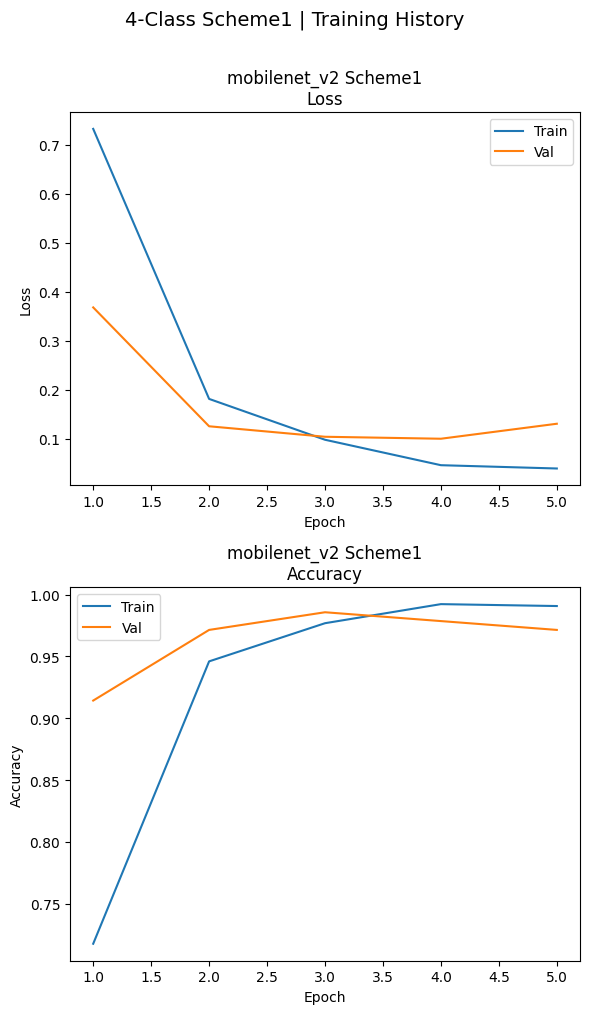

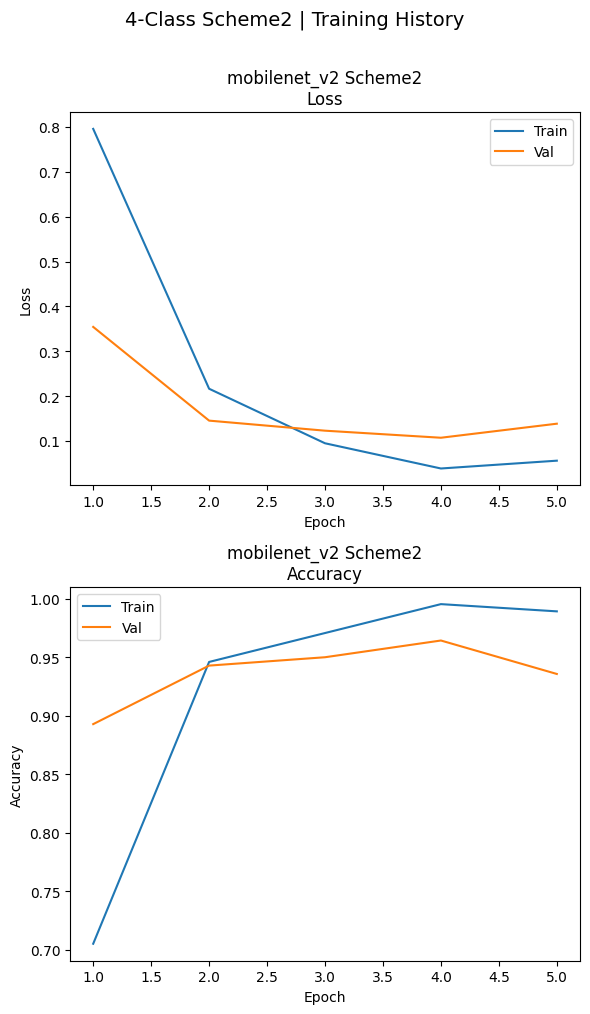

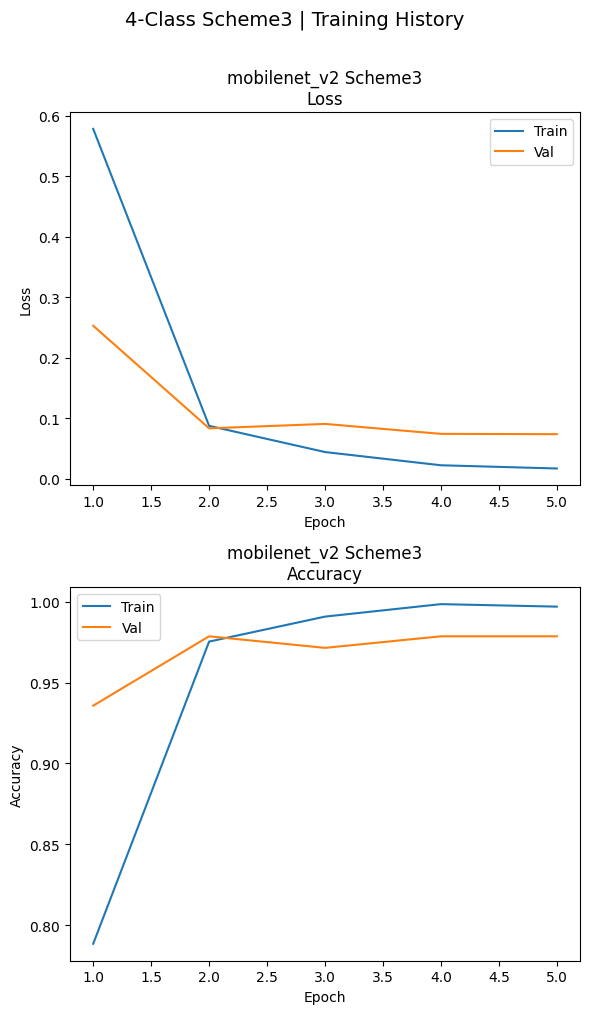

In [7]:
# Plot training curves for 4-class task across all models and schemes
plot_training_history(
    histories={
        f"{model} Scheme1": all_histories[model]["scheme1_4class"]
        for model in MODELS
    },
    title_prefix="4-Class Scheme1 | "
)

plot_training_history(
    histories={
        f"{model} Scheme2": all_histories[model]["scheme2_4class"]
        for model in MODELS
    },
    title_prefix="4-Class Scheme2 | "
)

plot_training_history(
    histories={
        f"{model} Scheme3": all_histories[model]["scheme3_4class"]
        for model in MODELS
    },
    title_prefix="4-Class Scheme3 | "
)

### 4.2 Training History – Task 2-Class

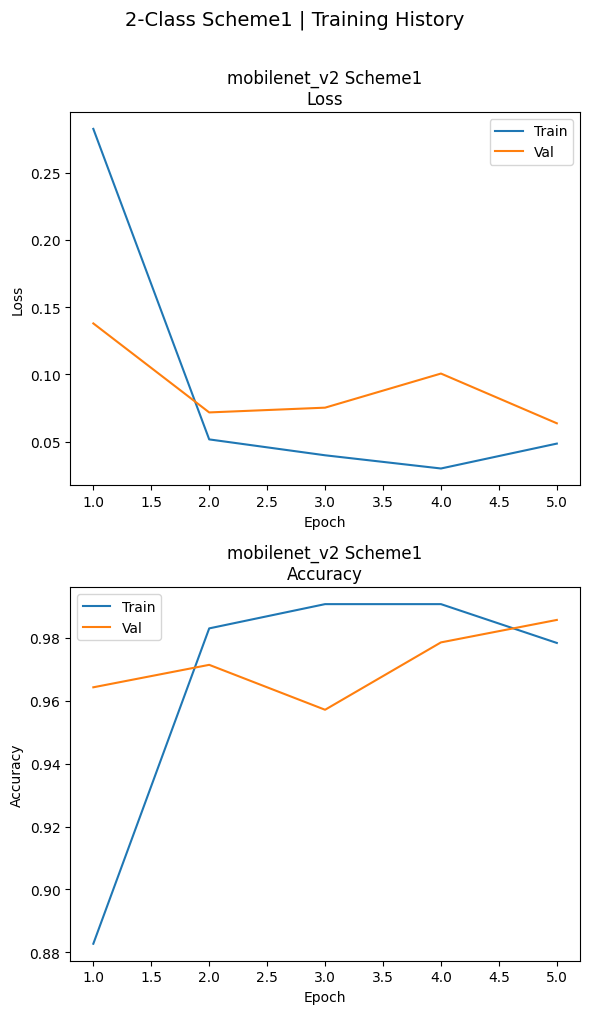

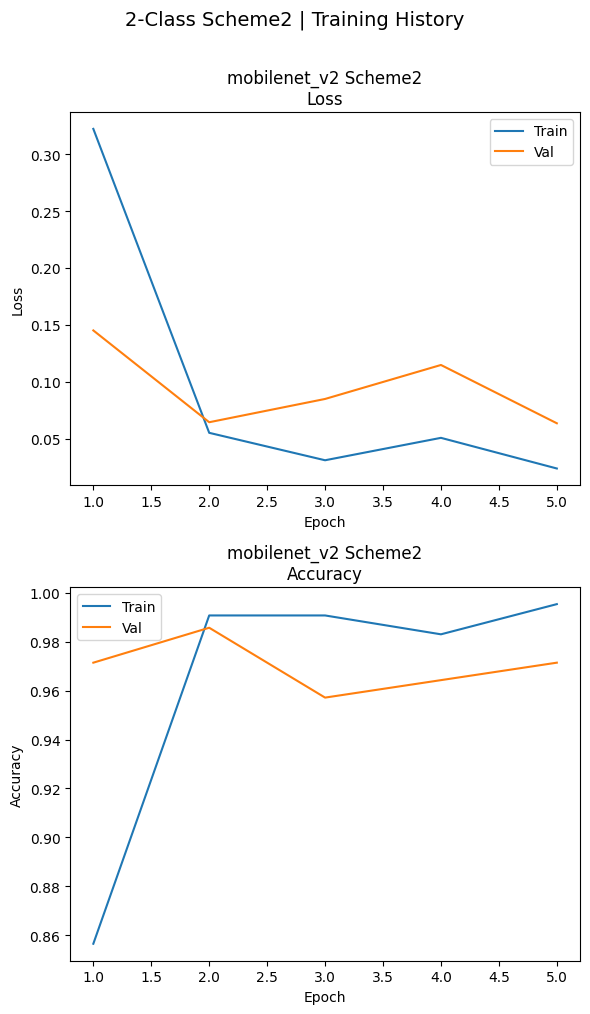

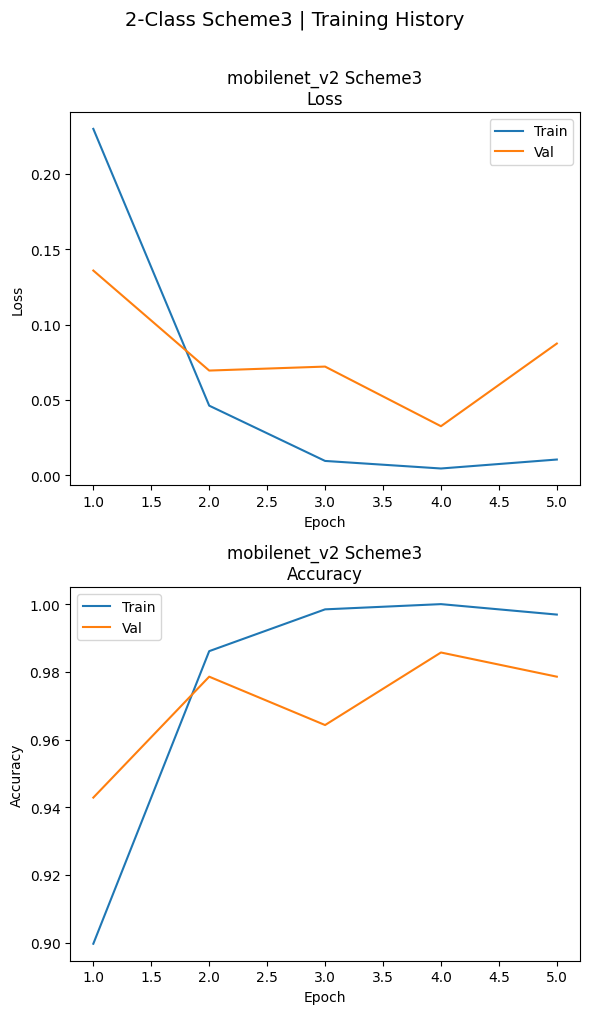

In [8]:
plot_training_history(
    histories={
        f"{model} Scheme1": all_histories[model]["scheme1_2class"]
        for model in MODELS
    },
    title_prefix="2-Class Scheme1 | "
)

plot_training_history(
    histories={
        f"{model} Scheme2": all_histories[model]["scheme2_2class"]
        for model in MODELS
    },
    title_prefix="2-Class Scheme2 | "
)

plot_training_history(
    histories={
        f"{model} Scheme3": all_histories[model]["scheme3_2class"]
        for model in MODELS
    },
    title_prefix="2-Class Scheme3 | "
)

### 4.3 Confusion Matrix – Task 4-Class

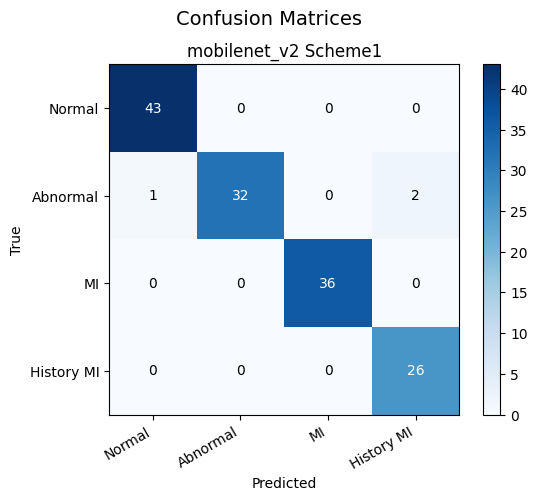

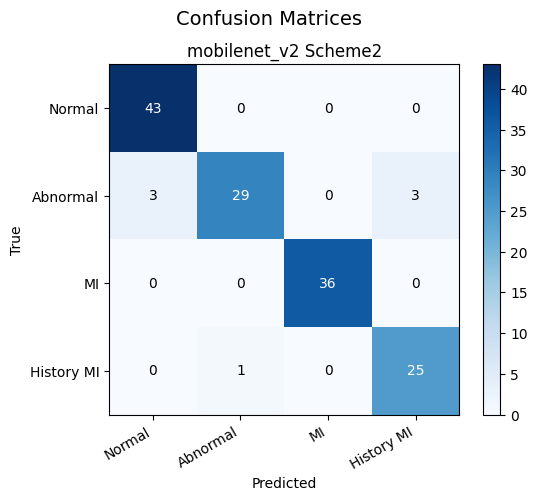

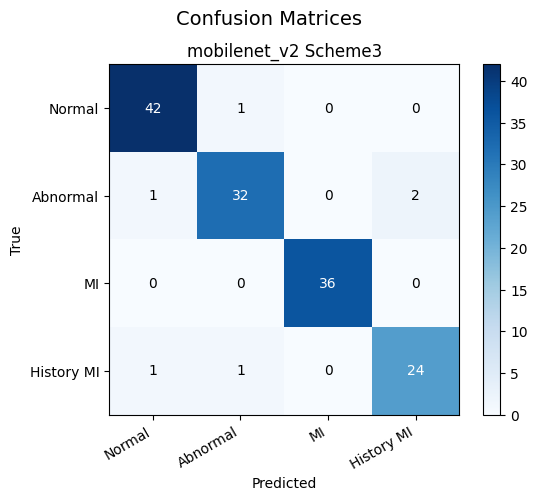

In [9]:
plot_confusion_matrices(
    results={
        f"{model} Scheme1": all_results[model]["scheme1_4class"]
        for model in MODELS
    },
    class_names=CLASS_NAMES_4
)

plot_confusion_matrices(
    results={
        f"{model} Scheme2": all_results[model]["scheme2_4class"]
        for model in MODELS
    },
    class_names=CLASS_NAMES_4
)

plot_confusion_matrices(
    results={
        f"{model} Scheme3": all_results[model]["scheme3_4class"]
        for model in MODELS
    },
    class_names=CLASS_NAMES_4
)

### 4.4 Confusion Matrix – Task 2-Class

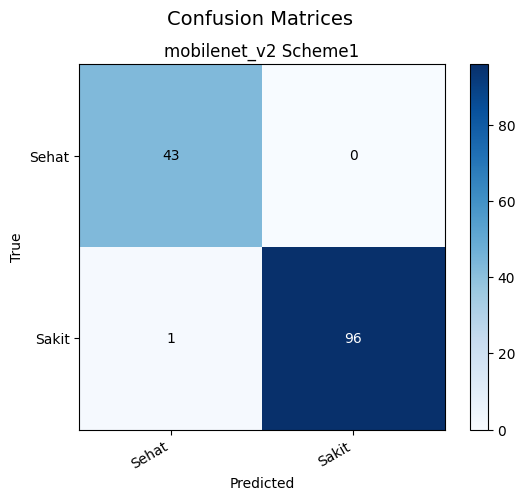

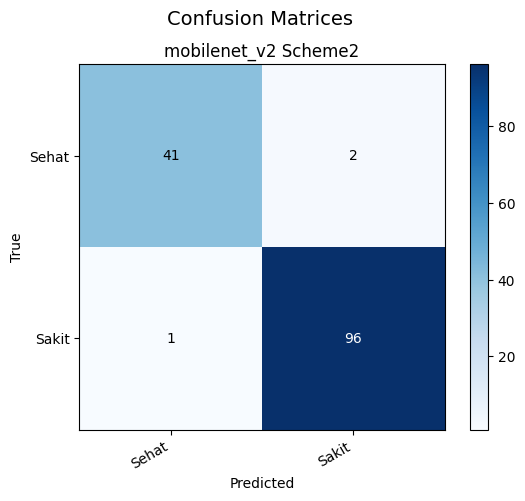

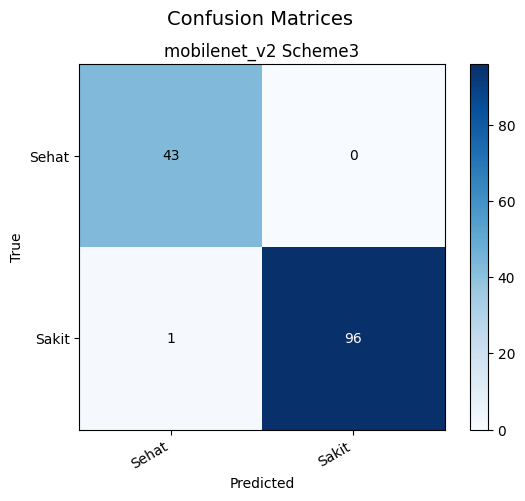

In [10]:
plot_confusion_matrices(
    results={
        f"{model} Scheme1": all_results[model]["scheme1_2class"]
        for model in MODELS
    },
    class_names=CLASS_NAMES_2
)

plot_confusion_matrices(
    results={
        f"{model} Scheme2": all_results[model]["scheme2_2class"]
        for model in MODELS
    },
    class_names=CLASS_NAMES_2
)

plot_confusion_matrices(
    results={
        f"{model} Scheme3": all_results[model]["scheme3_2class"]
        for model in MODELS
    },
    class_names=CLASS_NAMES_2
)

### 4.5 Perbandingan Akurasi Semua Model

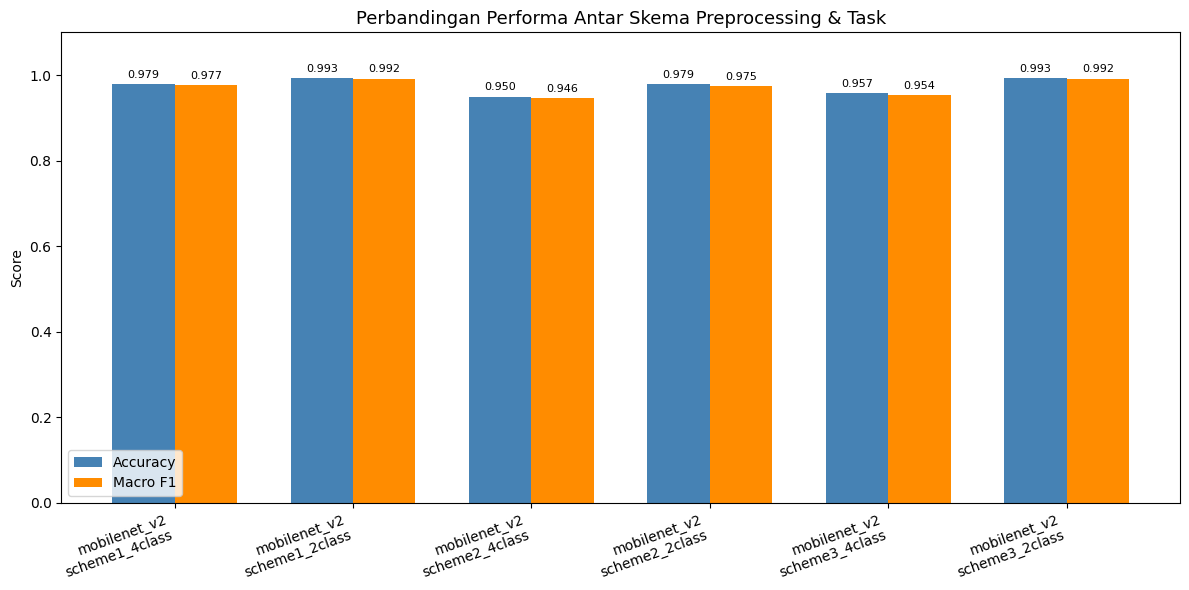

In [11]:
# Create comparison plot across all models
all_results_flat = {}
for model_name in MODELS:
    for scheme_task, result in all_results[model_name].items():
        key = f"{model_name}\n{scheme_task}"
        all_results_flat[key] = result

plot_scheme_comparison(all_results_flat)

### 4.6 Sample Predictions – Best Model

Best overall model: mobilenet_v2 (avg accuracy: 0.9750)


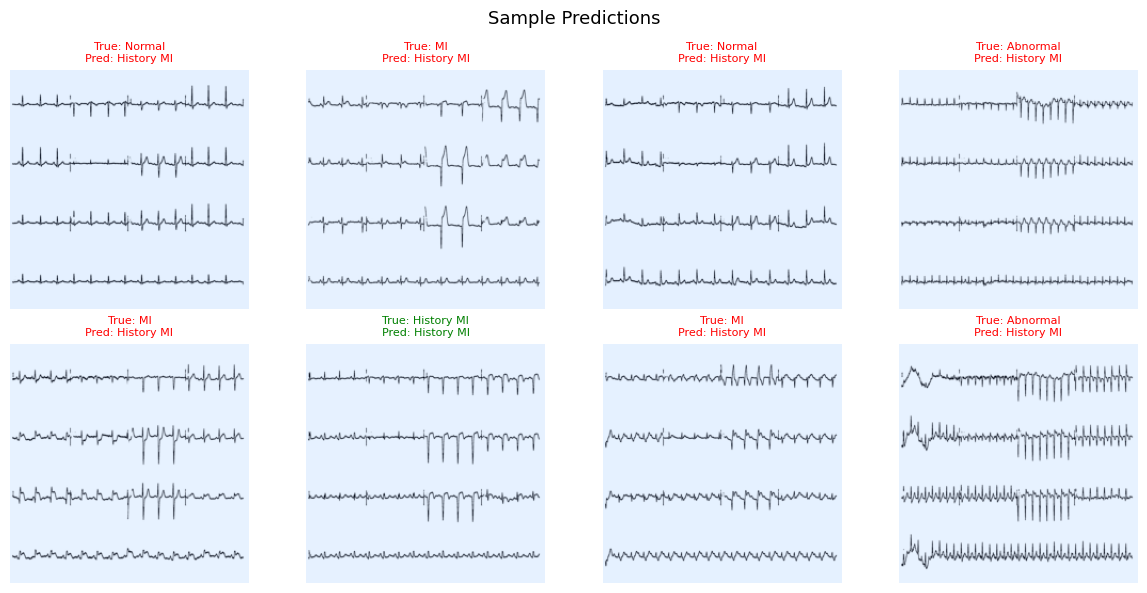

In [12]:
from utils.modeling import plot_sample_predictions

# Find best overall model (highest average accuracy across all tasks)
best_overall_model = max(
    MODELS,
    key=lambda m: np.mean([all_results[m][k]["accuracy"] for k in all_results[m]])
)
best_avg_acc = np.mean([all_results[best_overall_model][k]["accuracy"] for k in all_results[best_overall_model]])

print(f"Best overall model: {best_overall_model} (avg accuracy: {best_avg_acc:.4f})")

# Use best model on Scheme1 4-class for sample predictions
best_model = build_model(num_classes=4, in_channels=3, backbone=best_overall_model).to(DEVICE)
records_best = _get_image_files_scheme1(Config.data_root)
dataset_best = ECGDatasetScheme1(records_best, task="4class", image_size=IMAGE_SIZE)

plot_sample_predictions(
    model=best_model,
    dataset=dataset_best,
    class_names=CLASS_NAMES_4,
    device=DEVICE,
    num_samples=8
)